# 📊 Notebook 1: Exploración de Datos

Este notebook cubre:
- Descarga y organización del dataset
- Exploración de la distribución de clases
- Verificación de imágenes
- División en train/val/test
- Visualización de muestras

In [11]:
# Imports
import sys
sys.path.append('..')

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from src.dataset.download import download_sample_dataset, validate_dataset, create_sample_structure
from src.dataset.preprocess import create_data_splits, analyze_dataset, verify_images
from src.utils.helpers import load_config

# Configuración de matplotlib
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

## 1. Configuración del Proyecto

In [12]:
# Cargar configuración
config = load_config('../config/config.yaml')
print("Configuración cargada:")
print(f"  - Número de clases: {config['dataset']['num_classes']}")
print(f"  - Tamaño de imagen: {config['dataset']['image_size']}")
print(f"  - Train split: {config['dataset']['train_split']}")
print(f"  - Val split: {config['dataset']['val_split']}")
print(f"  - Test split: {config['dataset']['test_split']}")

Configuración cargada:
  - Número de clases: 30
  - Tamaño de imagen: 224
  - Train split: 0.7
  - Val split: 0.15
  - Test split: 0.15


## 2. Descarga del Dataset

**IMPORTANTE:** Debes descargar un dataset real de plantas medicinales.

### Opción A: Kaggle (Recomendado)

```bash
# En terminal:
kaggle datasets download -d aryashah2k/indian-medicinal-leaves-dataset
unzip indian-medicinal-leaves-dataset.zip -d ../data/raw/
```

### Opción B: Dataset Personalizado

Organiza tus imágenes en `data/raw/` con esta estructura:
```
data/raw/
├── aloe_vera/
│   ├── img_001.jpg
│   └── ...
├── manzanilla/
│   └── ...
└── ...
```

In [13]:
# Mostrar instrucciones de descarga
download_sample_dataset(output_dir='../data/raw')

DESCARGA DE DATASET DE PLANTAS MEDICINALES

Para este proyecto, necesitas descargar un dataset real.

OPCIÓN 1 - Kaggle (Recomendado):
----------------------------------------------------------------------
1. Dataset: 'Indian Medicinal Leaves Dataset'
   URL: https://www.kaggle.com/datasets/aryashah2k/indian-medicinal-leaves-dataset

   Pasos:
   a) Instala kaggle CLI: pip install kaggle
   b) Configura tus credenciales en ~/.kaggle/kaggle.json
   c) Descarga:
      kaggle datasets download -d aryashah2k/indian-medicinal-leaves-dataset
   d) Descomprime en data/raw/

2. Dataset alternativo: 'Medicinal Plant Dataset'
   URL: https://www.kaggle.com/datasets/swastikadutta/medicinal-plant-dataset

OPCIÓN 2 - Crear tu propio dataset:
----------------------------------------------------------------------
Si quieres crear un dataset personalizado:
1. Crea carpetas en data/raw/ con nombres de plantas:
   data/raw/aloe_vera/
   data/raw/manzanilla/
   data/raw/menta/
   etc.

2. Coloca al menos

In [14]:
# Crear estructura de carpetas de ejemplo (opcional)
# Descomentar si quieres crear un dataset de ejemplo
# create_sample_structure('../data/raw')

## 3. Validación del Dataset

In [15]:
# Validar dataset
is_valid = validate_dataset('../data/raw', min_images_per_class=10)


✓ Se encontraron 99 clases:

  ✓ Aloevera                  -  118 imágenes
  ✓ Amla                      -   67 imágenes
  ✓ Amruthaballi              -   91 imágenes
  ✓ Arali                     -   89 imágenes
  ✓ Arive Dantu               -  122 imágenes
  ✓ Arjun                     - 1610 imágenes
  ✓ Astma_weed                -   82 imágenes
  ✓ Badipala                  -   76 imágenes
  ✓ Balloon_Vine              -   61 imágenes
  ✓ Bamboo                    -  118 imágenes
  ✓ Basale                    -  103 imágenes
  ✓ Beans                     -   97 imágenes
  ✓ Betel                     -  162 imágenes
  ✓ Bhrami                    -  104 imágenes
  ✓ Bringaraja                -   73 imágenes
  ✓ Caricature                -   76 imágenes
  ✓ Castor                    -  129 imágenes
  ✓ Catharanthus              -  134 imágenes
  ✓ Chakte                    -   68 imágenes
  ✓ Chilly                    -   69 imágenes
  ✓ Citron lime (herelikai)   -   99 imágenes
  ✓ 

## 4. Análisis del Dataset

In [16]:
# Analizar distribución de clases
stats = analyze_dataset('../data/raw')


Analizando dataset en ../data/raw...
Número de clases: 99
Total de imágenes: 18340
Promedio por clase: 185.3
Mínimo por clase: 8
Máximo por clase: 1878

Distribución por clase:
----------------------------------------------------------------------
  Mint                      1878 ██████████████████████████████████████████████████
  Curry                     1838 ████████████████████████████████████████████████
  Neem                      1802 ███████████████████████████████████████████████
  Arjun                     1610 ██████████████████████████████████████████
  Marsh Pennywort           1610 ██████████████████████████████████████████
  Rubble                    1610 ██████████████████████████████████████████
  Tulsi                      229 ██████
  Guava                      193 █████
  Lemon                      180 ████
  Jasmine                    176 ████
  Tamarind                   176 ████
  Jackfruit                  166 ████
  Mango                      165 ████
  Betel

## 5. Verificación de Imágenes

In [17]:
# Verificar que todas las imágenes se puedan abrir
valid_count, corrupted_count = verify_images('../data/raw', fix_corrupted=False)

if corrupted_count > 0:
    print("\n⚠️ Se encontraron imágenes corruptas.")
    print("Ejecuta con fix_corrupted=True para eliminarlas.")


Verificando imágenes en ../data/raw...

✓ Verificación completa:
  Válidas:   18415
  Corruptas: 0


## 6. División del Dataset (Train/Val/Test)

In [18]:
# Crear splits
create_data_splits(
    source_dir='../data/raw',
    output_dir='../data/processed',
    train_ratio=config['dataset']['train_split'],
    val_ratio=config['dataset']['val_split'],
    test_ratio=config['dataset']['test_split'],
    seed=42
)


Dividiendo dataset en Train/Val/Test...
  Train: 70.0%
  Val:   15.0%
  Test:  15.0%



Procesando clases: 100%|██████████| 99/99 [00:25<00:00,  3.95it/s]


✓ Dataset dividido exitosamente:
  Train: 12797 imágenes
  Val:   2707 imágenes
  Test:  2836 imágenes
  Total: 18340 imágenes

Datos guardados en: ../data/processed


## 7. Visualización de Muestras

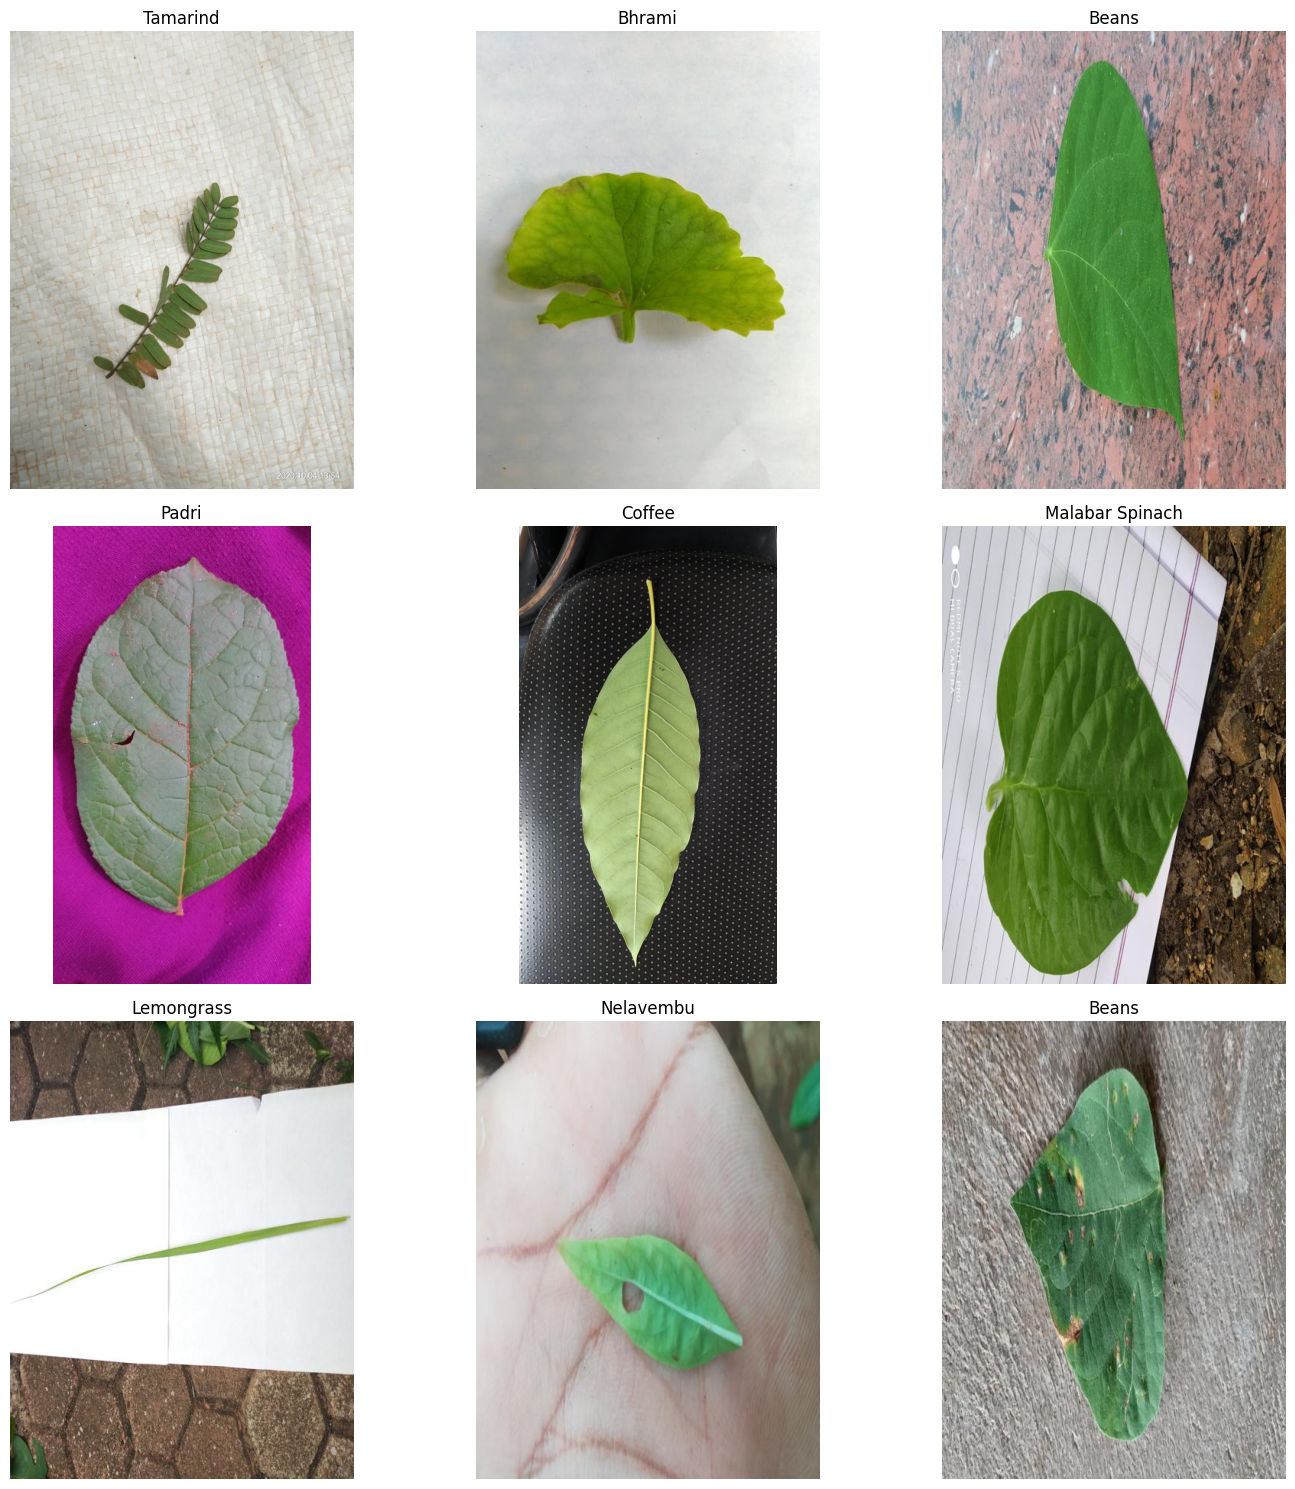

In [19]:
# Visualizar muestras aleatorias
def visualize_samples(data_dir, num_samples=9):
    """Visualiza muestras aleatorias del dataset."""
    classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes = axes.ravel()
    
    for i in range(min(num_samples, len(axes))):
        # Seleccionar clase aleatoria
        class_name = np.random.choice(classes)
        class_dir = os.path.join(data_dir, class_name)
        
        # Seleccionar imagen aleatoria
        images = [f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
        if images:
            img_name = np.random.choice(images)
            img_path = os.path.join(class_dir, img_name)
            
            # Cargar y mostrar imagen
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(class_name.replace('_', ' ').title(), fontsize=12)
            axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualizar del conjunto de entrenamiento
visualize_samples('../data/processed/train', num_samples=9)

## 8. Resumen

### Próximos pasos:
1. ✅ Dataset descargado y organizado
2. ✅ Datos divididos en train/val/test
3. ➡️ Continuar con `02_entrenamiento_modelo.ipynb`

In [20]:
print("\n" + "="*70)
print("✓ Exploración de datos completada")
print("="*70)
print("\nPróximo paso: Abrir 02_entrenamiento_modelo.ipynb")


✓ Exploración de datos completada

Próximo paso: Abrir 02_entrenamiento_modelo.ipynb
